# Companies Stock Forecasting Model

## Importing

In [1]:
import mlflow
import dagshub
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from prophet import Prophet
from utils import *

/home/marcos/mle-specialization-03/mles3-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## Loading Processed Data

In [2]:
data = joblib.load("../data/processed/processed_data.joblib")

In [3]:
X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]
X_train_sample = data["X_train_sample"]
y_train_sample = data["y_train_sample"]

## Model Implementation

### DagsHub

In [4]:
"""
Initializating DagsHub
"""
dagshub.init(repo_owner=REPOSITORY_OWNER, repo_name=REPOSITORY_NAME, mlflow=True)

Accessing as MaCh1Ne01

Initialized MLflow to track repo "MaCh1Ne01/mle-specialization-03"

Repository MaCh1Ne01/mle-specialization-03 initialized!

### MLflow

In [5]:
mlflow.set_tracking_uri(MLFLOW_DAGSHUB_URL)

In [6]:
setting_experiment()

Experiment Companies Stock Forecasting - MLE 03 Project already exists. Using existing one.
ID: 0


In [7]:
mlflow.autolog(disable=True,)

### Models

In [8]:
base_model = DummyRegressor(strategy="mean")

In [9]:
model_01 = ElasticNet(random_state=SEED, max_iter=5000)
search_space_model_01 = {
    "alpha": Continuous(0.001, 1.0, distribution="log-uniform"),
    "l1_ratio": Continuous(0.1, 0.9),
    "selection": Categorical(["cyclic", "random"])
    }

In [10]:
model_02 = XGBRegressor(random_state=SEED, verbosity=0)
search_space_model_02 = {
    "learning_rate": Continuous(0.01, 0.3, distribution="log-uniform"),
    "max_depth": Integer(3, 10),
    "n_estimators": Integer(50, 300),
    "subsample": Continuous(0.6, 1.0)
    }

In [11]:
model_03 = LGBMRegressor(random_state=SEED, verbose=-1)
search_space_model_03 = {
    "learning_rate": Continuous(0.01, 0.3, distribution="uniform"),
    "n_estimators": Integer(100, 500), 
    "num_leaves": Integer(31, 127)
    }

In [12]:
model_04 = RidgeModelStackingEnsemble(base_models=[model_01,model_02,model_03], alpha=1.0, random_state=SEED)

## Training

In [14]:
base_model_metrics, base_model = executing_and_saving_regression_model(model=base_model, model_name=BASE_MODEL_NAME, X=X_train, y=y_train, X_sample=None, y_sample=None,\
                                                                       X_test=X_test, y_test=y_test, label_data=TESTING_DATA_LABEL, search_space=None)

🏃 View run Dummy Regressor Model Run at: https://dagshub.com/MaCh1Ne01/mle-specialization-03.mlflow/#/experiments/0/runs/7b24136681b544fb8b3826f751eecfe1
🧪 View experiment at: https://dagshub.com/MaCh1Ne01/mle-specialization-03.mlflow/#/experiments/0
**********Dummy Regressor Metrics (Testing Data):**********
Mean Absolute Error: 128.1691
Root Mean Squared Error: 350.8374
Square R: -0.0117
Mean Absolute Percentage Error: 241.3761
Symmetric Mean Absolute Percentage Error: 74.9349


In [15]:
model_01_metrics, model_01 = executing_and_saving_regression_model(model=model_01, model_name=MODEL_01_NAME, X=X_train, y=y_train, X_sample=X_train_sample, y_sample=y_train_sample,\
                                                         X_test=X_test, y_test=y_test, label_data=TESTING_DATA_LABEL, search_space=search_space_model_01)

gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	4     	-9.83254	6.51083    	-3.48184   	-18.5986   
1  	8     	-7.34564	6.49693    	-3.48184   	-18.598    
2  	8     	-3.42327	0.395063   	-2.739     	-3.65136   
3  	8     	-2.87245	0.475521   	-2.36043   	-3.65136   
4  	8     	-2.28008	0.00211039 	-2.27886   	-2.28373   
🏃 View run ElasticNet Model Run at: https://dagshub.com/MaCh1Ne01/mle-specialization-03.mlflow/#/experiments/0/runs/0fe29650282b4d018c51d7f081ec644c
🧪 View experiment at: https://dagshub.com/MaCh1Ne01/mle-specialization-03.mlflow/#/experiments/0
**********ElasticNet Metrics (Testing Data):**********
Mean Absolute Error: 1.1235
Root Mean Squared Error: 3.2607
Square R: 0.9999
Mean Absolute Percentage Error: 0.6843
Symmetric Mean Absolute Percentage Error: 0.6839


In [16]:
model_02_metrics, model_02 = executing_and_saving_regression_model(model=model_02, model_name=MODEL_02_NAME, X=X_train, y=y_train, X_sample=X_train_sample, y_sample=y_train_sample,\
                                                         X_test=X_test, y_test=y_test, label_data=TESTING_DATA_LABEL, search_space=search_space_model_02)

gen	nevals	fitness	fitness_std	fitness_max	fitness_min
0  	4     	-76.166	0.798344   	-75.0299   	-77.2522   
1  	8     	-75.9177	0.409726   	-75.2798   	-76.277    
2  	8     	-75.8918	0.370322   	-75.2798   	-76.277    
3  	8     	-75.4811	0.623828   	-74.861    	-76.1973   
4  	8     	-74.7112	0.415157   	-74.3047   	-75.2369   


/home/marcos/mle-specialization-03/mles3-env/lib/python3.11/site-packages/xgboost/sklearn.py:1115: UserWarning: [21:37:22] WARNING: /workspace/src/c_api/c_api.cc:1575: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)


🏃 View run XGBoost Regressor Model Run at: https://dagshub.com/MaCh1Ne01/mle-specialization-03.mlflow/#/experiments/0/runs/4f4f93658a464f51b567ddafd977062e
🧪 View experiment at: https://dagshub.com/MaCh1Ne01/mle-specialization-03.mlflow/#/experiments/0
**********XGBoost Regressor Metrics (Testing Data):**********
Mean Absolute Error: 9.1589
Root Mean Squared Error: 89.4397
Square R: 0.9342
Mean Absolute Percentage Error: 9.2193
Symmetric Mean Absolute Percentage Error: 6.0524


In [17]:
model_03_metrics, model_03 = executing_and_saving_regression_model(model=model_03, model_name=MODEL_03_NAME, X=X_train, y=y_train, X_sample=X_train_sample, y_sample=y_train_sample,\
                                                         X_test=X_test, y_test=y_test, label_data=TESTING_DATA_LABEL, search_space=search_space_model_03)

gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	4     	-67.6147	2.15736    	-64.2107   	-69.7868   
1  	8     	-59.1457	5.06503    	-54.0806   	-64.2107   
2  	8     	-57.9883	4.34225    	-53.9227   	-64.2107   
3  	8     	-53.9227	0          	-53.9227   	-53.9227   
4  	8     	-53.9305	0.0136096  	-53.9227   	-53.9541   
🏃 View run LightGBM Regressor Model Run at: https://dagshub.com/MaCh1Ne01/mle-specialization-03.mlflow/#/experiments/0/runs/8adfa934c43b4ddcaf6336daa98002f4
🧪 View experiment at: https://dagshub.com/MaCh1Ne01/mle-specialization-03.mlflow/#/experiments/0
**********LightGBM Regressor Metrics (Testing Data):**********
Mean Absolute Error: 9.0139
Root Mean Squared Error: 89.7740
Square R: 0.9338
Mean Absolute Percentage Error: 6.4854
Symmetric Mean Absolute Percentage Error: 4.9224


In [18]:
model_04 = RidgeModelStackingEnsemble(base_models=[model_01,model_02,model_03], alpha=1.0, random_state=SEED)
model_04_metrics, model_04 = executing_and_saving_regression_model(model=model_04, model_name=MODEL_04_NAME, X=X_train, y=y_train, X_sample=None, y_sample=None,\
                                                                   X_test=X_test, y_test=y_test, label_data=TESTING_DATA_LABEL, search_space=None)

/home/marcos/mle-specialization-03/mles3-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(
/home/marcos/mle-specialization-03/mles3-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/marcos/mle-specialization-03/mles3-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(
/home/marcos/mle-specialization-03/mles3-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


🏃 View run Ridge Stacking Ensemble Model Run at: https://dagshub.com/MaCh1Ne01/mle-specialization-03.mlflow/#/experiments/0/runs/3264ea81c3c54f38976b72b6c39ca278
🧪 View experiment at: https://dagshub.com/MaCh1Ne01/mle-specialization-03.mlflow/#/experiments/0
**********Ridge Stacking Ensemble Metrics (Testing Data):**********
Mean Absolute Error: 1.1213
Root Mean Squared Error: 3.2515
Square R: 0.9999
Mean Absolute Percentage Error: 0.6817
Symmetric Mean Absolute Percentage Error: 0.6817


## Predicting

In [19]:
"""
This section will be simulated with the same testing data
"""
base_model_predictions = predicting_regression_model(model=base_model, model_name=BASE_MODEL_NAME, X=X_test)

Dummy Regressor model: 120789 values were predicted and saved.


In [20]:
model_01_predictions = predicting_regression_model(model=model_01, model_name=MODEL_01_NAME, X=X_test)

ElasticNet model: 120789 values were predicted and saved.


In [21]:
model_02_predictions = predicting_regression_model(model=model_02, model_name=MODEL_02_NAME, X=X_test)

XGBoost Regressor model: 120789 values were predicted and saved.


In [22]:
model_03_predictions = predicting_regression_model(model=model_03, model_name=MODEL_03_NAME, X=X_test)

LightGBM Regressor model: 120789 values were predicted and saved.


In [23]:
model_04_predictions = predicting_regression_model(model=model_04, model_name=MODEL_04_NAME, X=X_test)

/home/marcos/mle-specialization-03/mles3-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(
/home/marcos/mle-specialization-03/mles3-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Ridge Stacking Ensemble model: 120789 values were predicted and saved.


## Visualizing

### Performance

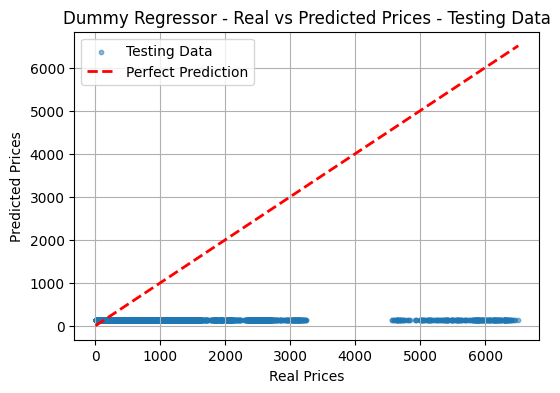

In [24]:
visualizing_regression_model_performance(model=base_model, model_name=BASE_MODEL_NAME, y=y_test, predictions=base_model_predictions, label_data=TESTING_DATA_LABEL)

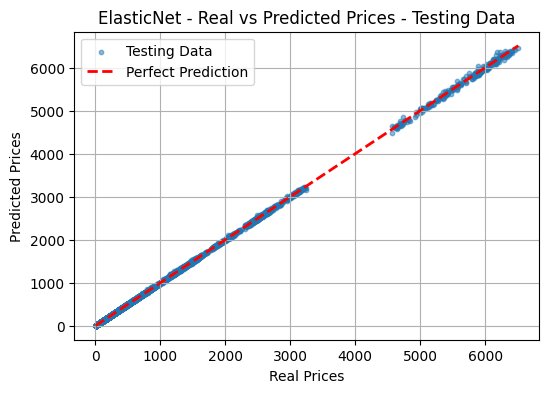

In [25]:
visualizing_regression_model_performance(model=model_01, model_name=MODEL_01_NAME, y=y_test, predictions=model_01_predictions, label_data=TESTING_DATA_LABEL)

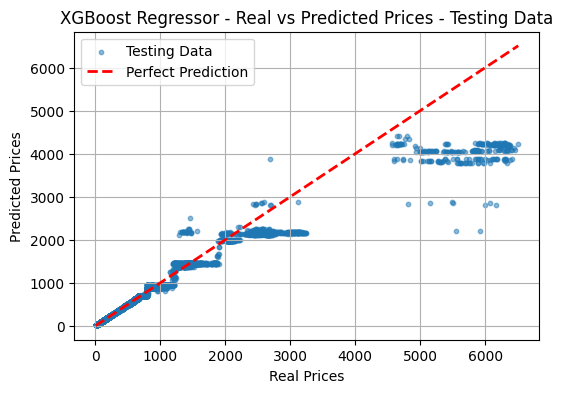

In [26]:
visualizing_regression_model_performance(model=model_02, model_name=MODEL_02_NAME, y=y_test, predictions=model_02_predictions, label_data=TESTING_DATA_LABEL)

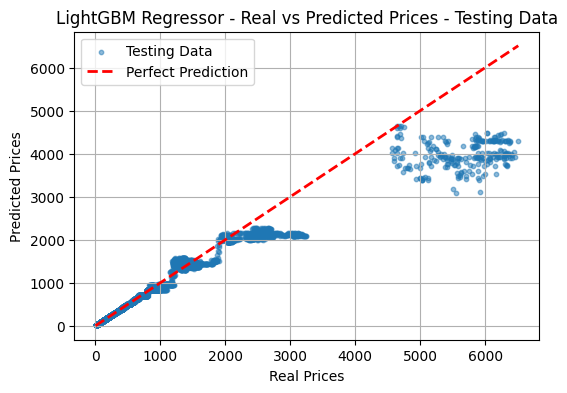

In [27]:
visualizing_regression_model_performance(model=model_03, model_name=MODEL_03_NAME, y=y_test, predictions=model_03_predictions, label_data=TESTING_DATA_LABEL)

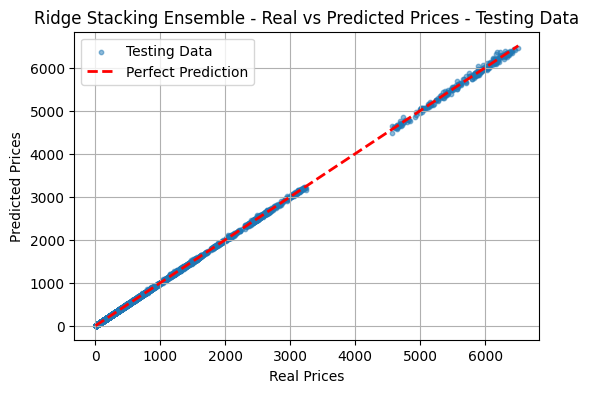

In [28]:
visualizing_regression_model_performance(model=model_04, model_name=MODEL_04_NAME, y=y_test, predictions=model_04_predictions, label_data=TESTING_DATA_LABEL)

### Temporal Serie for Apple - Prophet

In [29]:
ts_data = joblib.load("../data/processed/ts_data.joblib")
ts_X_train = ts_data["X_train"]
ts_y_train = ts_data["y_train"]
ts_X_test = ts_data["X_test"]
ts_y_test = ts_data["y_test"]

In [30]:
prophet_model = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False, seasonality_mode="additive",\
                        changepoint_prior_scale=0.01, changepoint_range=0.95, seasonality_prior_scale=5.0)

ts_training_data, ts_testing_data, ts_training_prophet, ts_testing_prophet = preparing_prophet_datasets(X_train=ts_X_train, y_train=ts_y_train, X_test=ts_X_test, y_test=ts_y_test,\
                                                                                                        temporal_feature="Date", target=TARGET, objective_feature=STRATIFY_FEATURE, objective_value="AAPL")             
prophet_model.fit(ts_training_prophet)
prophet_predictions = prophet_model.predict(ts_testing_prophet)
prophet_y_pred = prophet_predictions["yhat"].values

printing_regression_model_metrics(model_name="Prophet", real=ts_testing_prophet["y"], predictions=prophet_y_pred, label_data=TESTING_DATA_LABEL)

21:39:51 - cmdstanpy - INFO - Chain [1] start processing
21:39:51 - cmdstanpy - INFO - Chain [1] done processing


**********Prophet Metrics (Testing Data):**********
Mean Absolute Error: 34.7913
Root Mean Squared Error: 39.3447
Square R: -3.4254
Mean Absolute Percentage Error: 20.0077
Symmetric Mean Absolute Percentage Error: 22.4798


In [31]:
future_data = prophet_model.make_future_dataframe(periods=len(ts_testing_prophet), include_history=True)
prophet_forecast = prophet_model.predict(future_data)

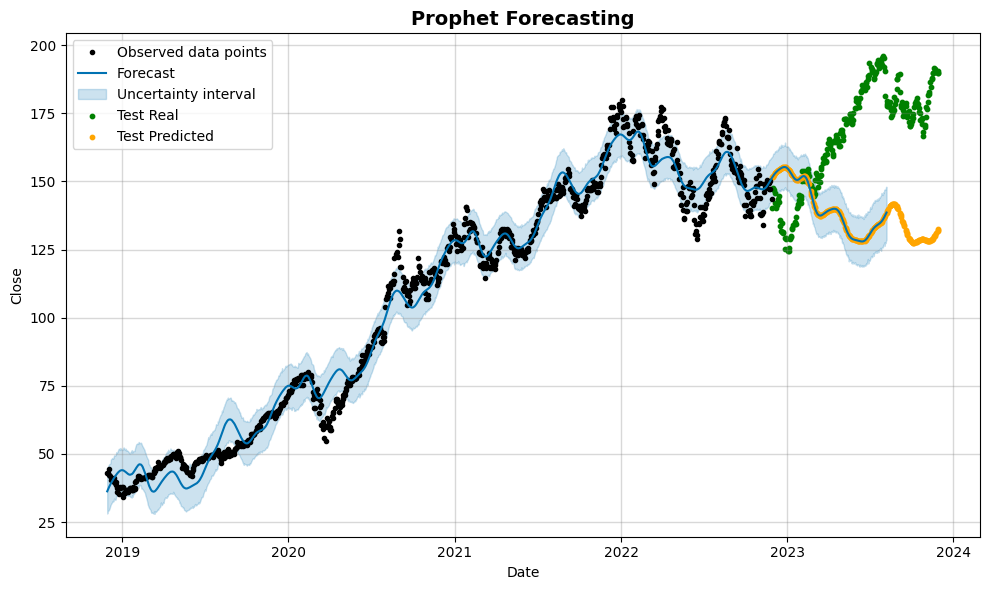

In [32]:
graphing_temporal_serie(model=prophet_model, model_name="Prophet", predictions_detail=prophet_forecast, X_test=ts_testing_prophet["ds"], y_test=ts_testing_prophet["y"],\
                        y_pred=prophet_y_pred, temporal_feature="Date", target=TARGET)

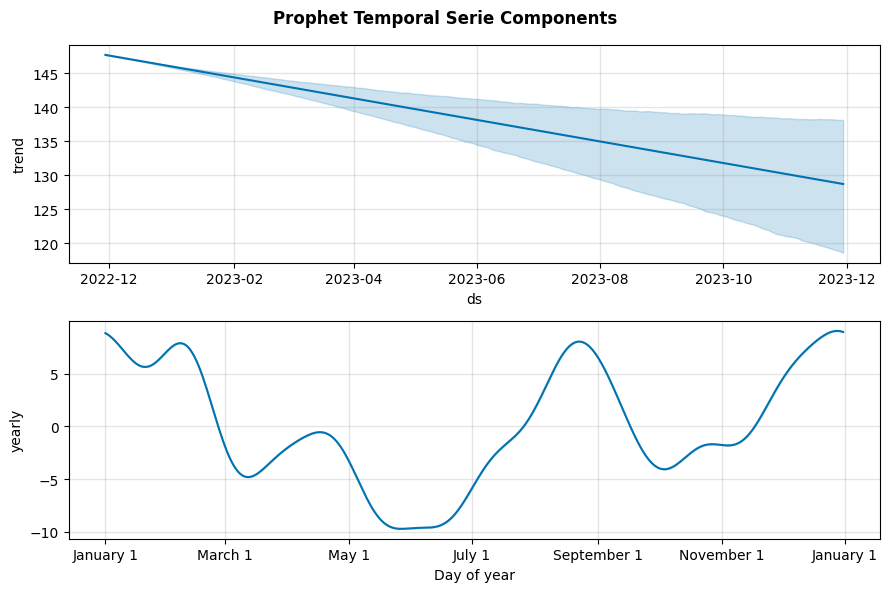

In [33]:
graphing_temporal_series_components(model=prophet_model, model_name="Prophet", predictions_detail=prophet_predictions)

## Results

### MAE, RMSE, R², MAPE and SMAPE

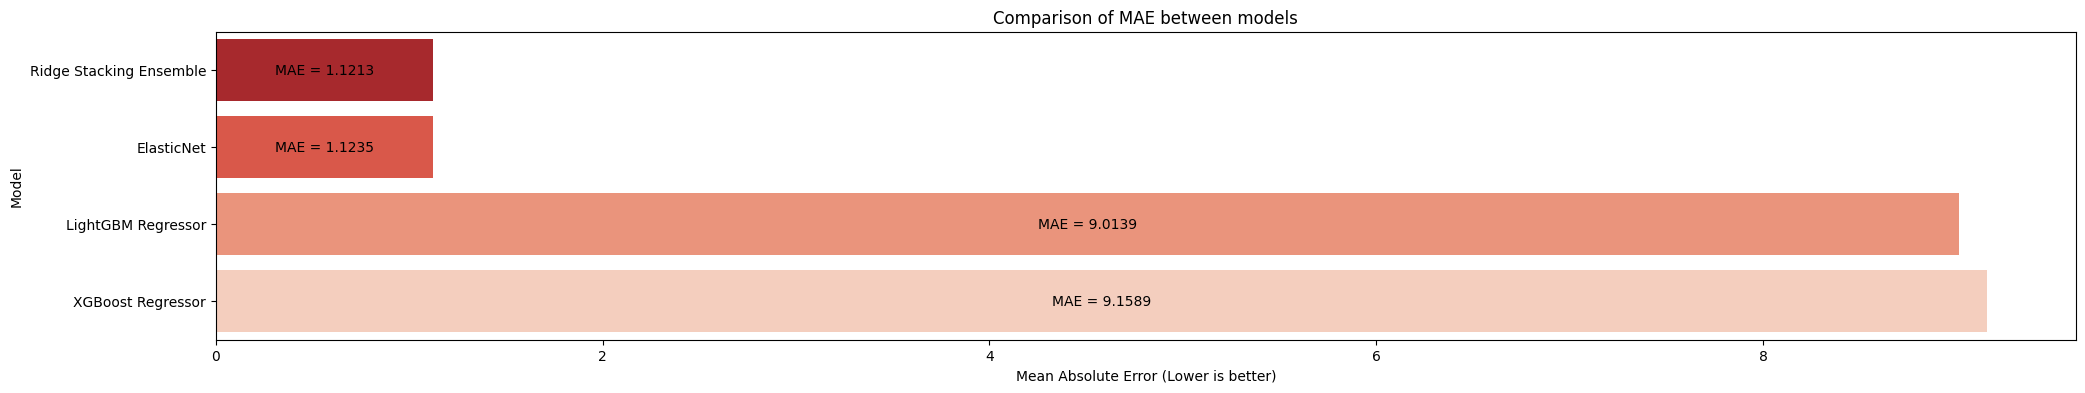

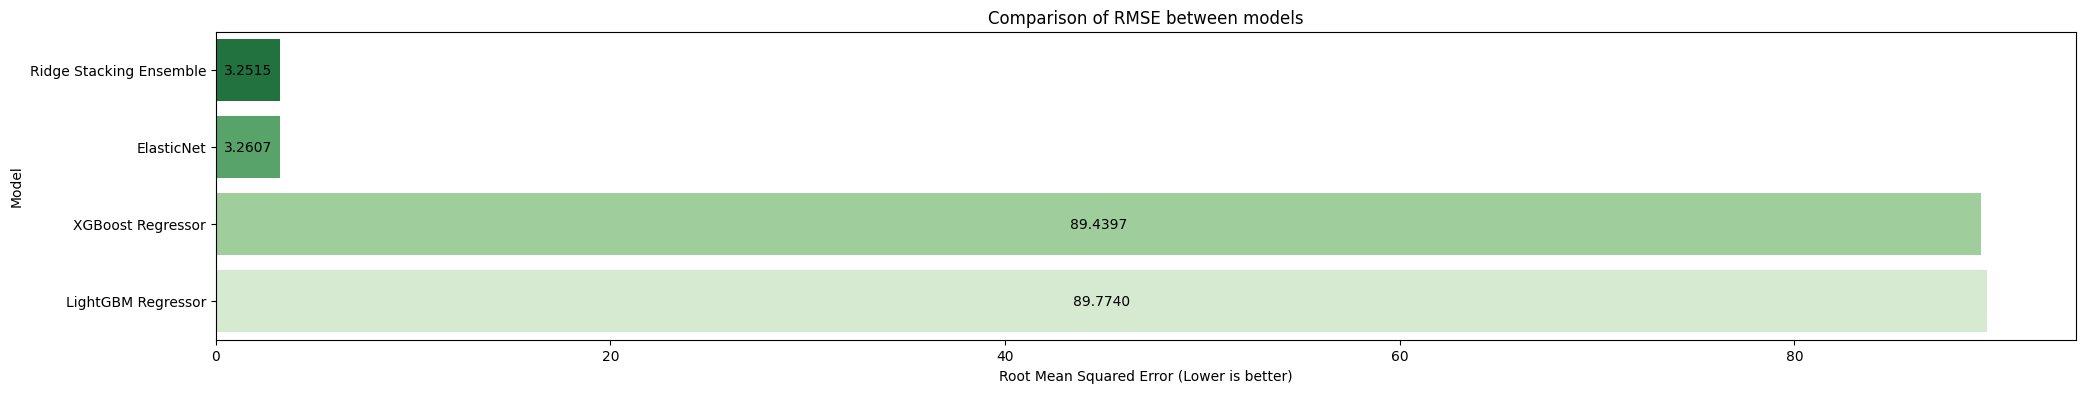

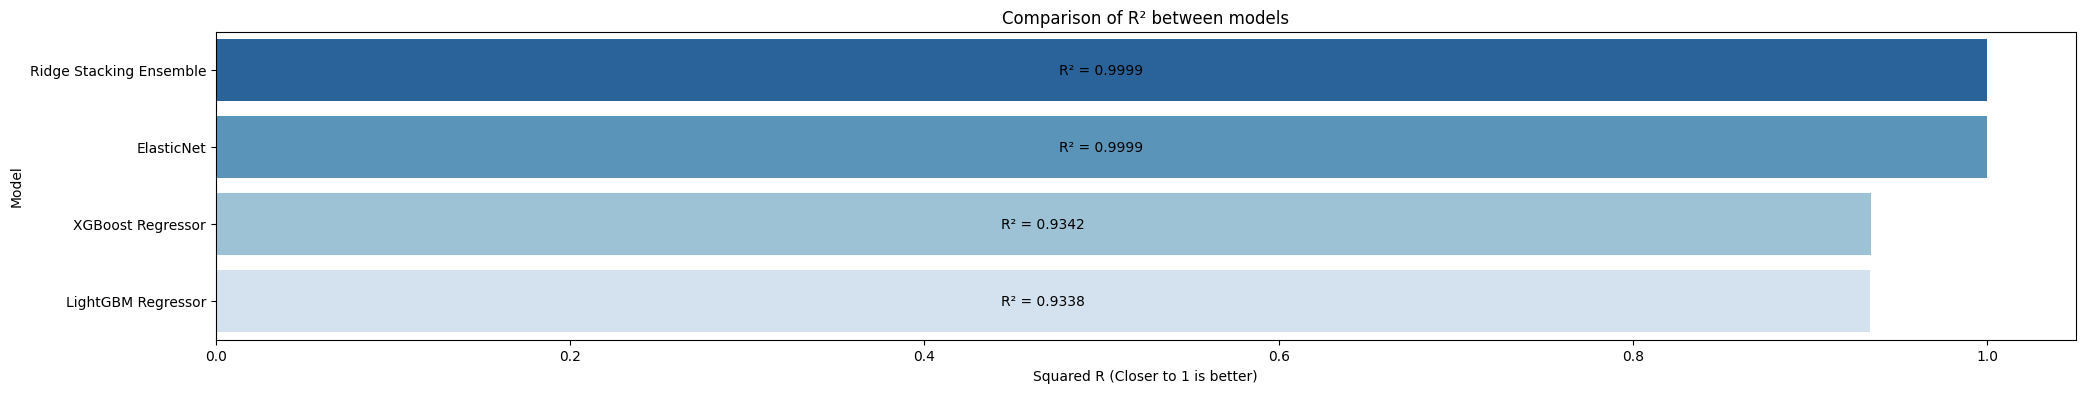

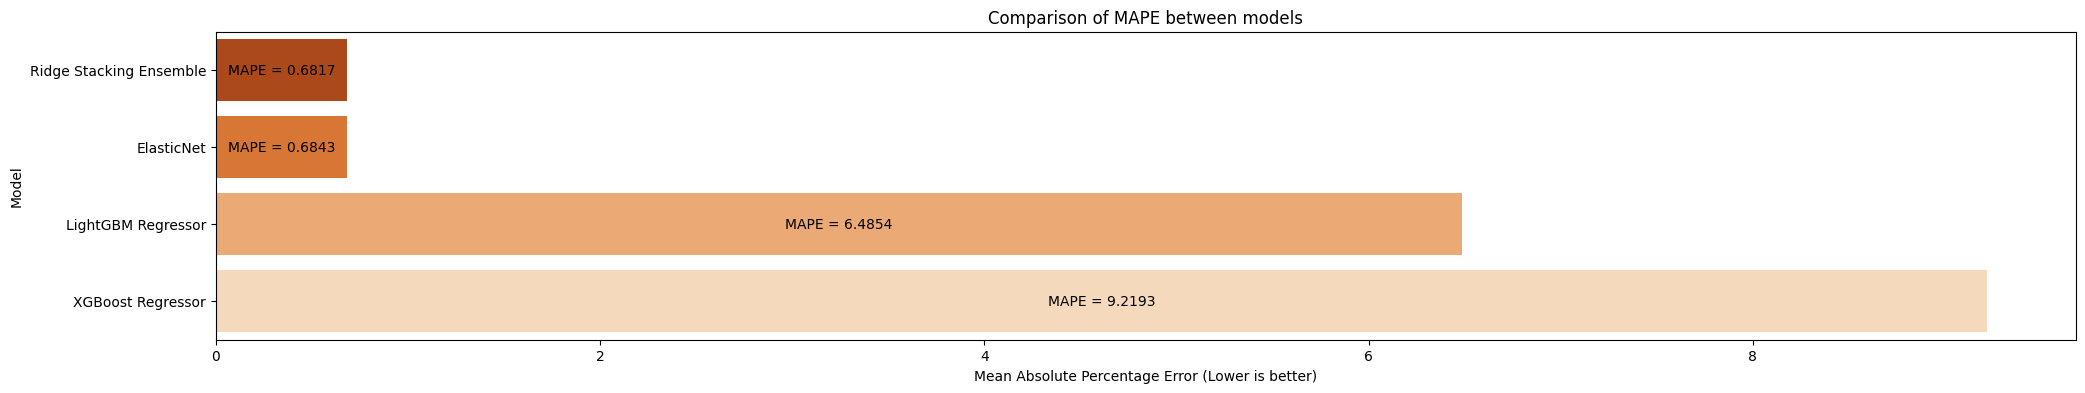

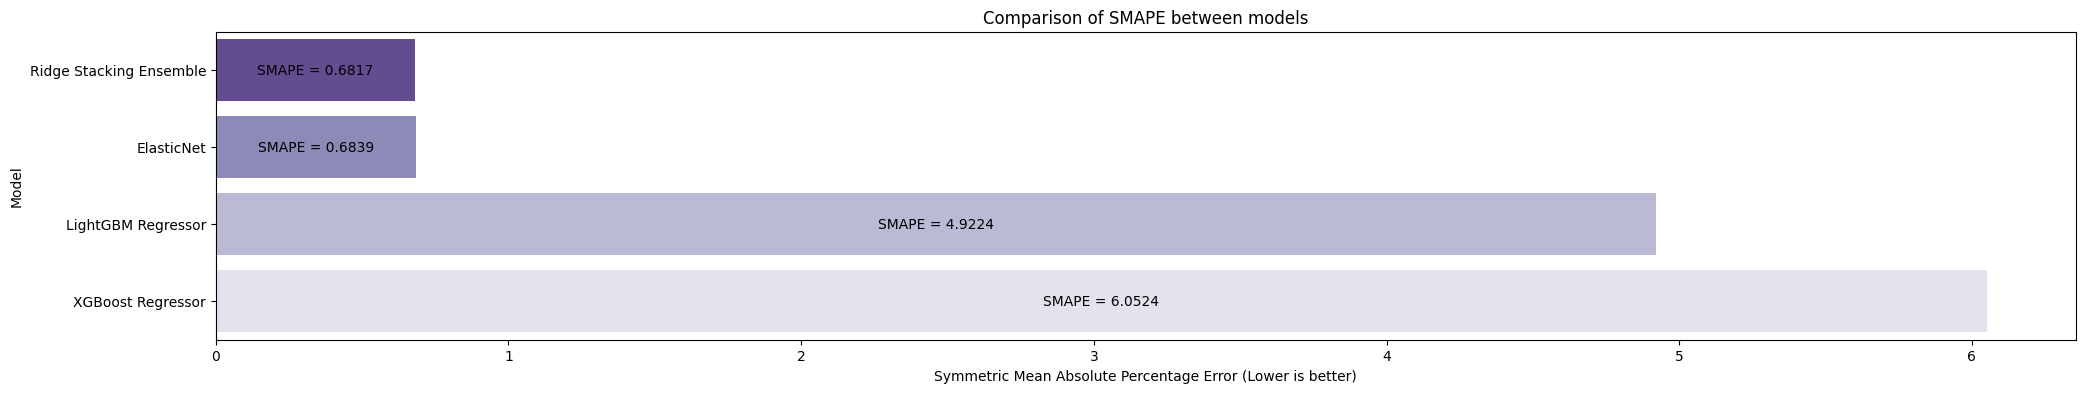

In [34]:
graphing_regression_models_results(metrics_01=model_01_metrics, metrics_02=model_02_metrics, metrics_03=model_03_metrics, metrics_04=model_04_metrics)